# Domain distance and transfer gain — comparing several (source, target) pairs

## Why this experiment is needed

The main experiment (3.2–3.5) observed that **"transfer works well on the endpoint with strong label correspondence"**.
But there were only three points (f_u / CL / t½), and **target size was aligned in the same direction as label correspondence**
(f_u 353 molecules, correspondence 0.70; CL 1027, 0.19; t½ 1164, 0.05). The size ablation did not fully separate the confound either.

Here, pairs with different domain distances are built for **the same endpoint (clearance)** and compared.
Fixing the endpoint rules out "because the endpoints differ" as an explanation.

| Pair | source | target | Nature |
|---|---|---|---|
| in vitro → human | microsomal CLint | human CL | reference point of the main experiment |
| in vitro → rat / dog / monkey | microsomal CLint | animal CL | **source fixed, only the target changes** |
| animal → human | rat+dog+monkey CL | human CL | the closest pair (both in vivo) |

Animal PK data come from PKSmart (Lombardo 2013, 371 compounds). 205 overlap with our target, so
**test molecules were removed from the source in every fold** to prevent leakage.

The representation is **RDKit descriptors**, the best in the QSAR comparison.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, spearmanr, pearsonr

ROOT = r'..'
CD = os.path.join(ROOT, 'results', 'cross_domain')
FIG = os.path.join(ROOT, 'results', 'figures')
os.makedirs(FIG, exist_ok=True)

ORDER = ['in vitro → human', 'in vitro → rat', 'in vitro → dog', 'in vitro → monkey', 'animal → human']
METHODS = ['PTFT', 'PTFT-shuffled', 'LCW', 'IVP']
COLOR = {'PTFT': '#1a7f37', 'PTFT-shuffled': '#8a8984', 'LCW': '#0969da', 'IVP': '#eb6834'}

runs = pd.read_csv(os.path.join(CD, 'runs.csv'))
corr = pd.read_csv(os.path.join(CD, 'correspondence.csv'))
print(f'{runs.seed.nunique()} seeds × {runs.fold.nunique()} folds × {runs.pair.nunique()} pairs')

pd.set_option('display.width', 220)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.6, 'axes.axisbelow': True})

3 seeds × 5 folds × 5 pairs


## 1. Label correspondence of each pair

`nn_rho` is the Spearman correlation between the labels of each target molecule and its structurally nearest source molecule (Tanimoto ≥ 0.4).
Same approach as 3.2 of the main experiment.

> **Limitation of the 1-NN approximation** — the in vitro source and the animal data share almost no molecules, so direct comparison is impossible.
> Within the animal data, however, the same molecule has both human and animal values, so it can be measured **directly**,
> and that value comes out higher than the 1-NN approximation (section 2 below). The two measurements are not mixed.

In [2]:
corr_view = corr.set_index('pair').loc[[p for p in ORDER if p in corr.pair.values]]
corr_view.round(3)

,nn_rho,n_pairs,median_sim,n_source,n_target_fit
pair,,,,,
in vitro → human,0.209,98,0.280,13566,657
in vitro → rat,0.313,57,0.305,13565,203
in vitro → dog,0.268,45,0.291,13565,162
in vitro → monkey,0.296,17,0.275,13565,78
animal → human,0.475,316,0.360,328,657


## 2. Reference: direct animal–human correspondence

The animal data contain human and animal values for the same molecules. Correlation is measured **directly** on shared molecules.
The order between species (monkey > dog > rat) is **set in advance by biology**, not chosen by us.
If that order matches label correspondence, the relation "biological distance → label correspondence"
holds outside our data as well.

In [3]:
a = pd.read_csv(os.path.join(ROOT, 'data', 'animal_pk', 'Animal_PK_data.csv'))
rows = []
for par, suf in [('CL', '_CL_mL_min_kg'), ('VDss', '_VDss_L_kg'), ('fup', '_fup')]:
    for sp in ('rat', 'dog', 'monkey'):
        h, x = 'human' + suf, sp + suf
        q = a[[h, x]].dropna()
        q = q[(q[h] > 0) & (q[x] > 0)]
        if len(q) < 10:
            continue
        rows.append({'parameter': par, 'species': sp, 'n': len(q),
                     'Pearson r': pearsonr(np.log10(q[h]), np.log10(q[x]))[0],
                     'Spearman ρ': spearmanr(np.log10(q[h]), np.log10(q[x]))[0]})
direct = pd.DataFrame(rows)
display(direct.pivot(index='parameter', columns='species', values='Spearman ρ')[
    ['rat', 'dog', 'monkey']].round(3))

print('Cross-species spread per parameter (smaller = correspondence holds as the species changes):')
for par, g in direct.groupby('parameter'):
    print(f"  {par:<5} {g['Spearman ρ'].min():.2f}–{g['Spearman ρ'].max():.2f}  "
          f"(range {g['Spearman ρ'].max() - g['Spearman ρ'].min():.2f})")

species,rat,dog,monkey
parameter,,,
CL,0.537,0.616,0.831
VDss,0.756,0.783,0.867
fup,0.805,0.798,0.737


Cross-species spread per parameter (smaller = correspondence holds as the species changes):
  CL    0.54–0.83  (range 0.29)
  VDss  0.76–0.87  (range 0.11)
  fup   0.74–0.81  (range 0.07)


**How to read** — f_u (fup) is expected to stay stable across species, while CL is expected to be species-sensitive.
Protein binding is mostly physicochemical with small species differences, whereas clearance depends on metabolic enzymes that differ by species.
This is **the same principle** as the endpoint order in the main experiment (f_u > CL > t½) —
the simpler the measurement mechanism, the better correspondence survives a change of domain.

## 3. Transfer gain

Seed mean per fold, then a paired t-test against that pair's TargetOnly (n = 5 folds).
`PTFT-shuffled` is the control with shuffled source labels; it tells whether the gain comes from label information.

In [4]:
fold_mean = runs.groupby(['pair', 'method', 'fold'])[['r2', 'rho', 'rmse']].mean()


def delta(pair, m, col='r2'):
    a_ = fold_mean.loc[(pair, m)][col]
    b_ = fold_mean.loc[(pair, 'TargetOnly')][col]
    d = a_ - b_
    se = d.std(ddof=1) / np.sqrt(len(d))
    return d.mean(), 2.776 * se, ttest_rel(a_, b_).pvalue


rows = []
for p in ORDER:
    if p not in runs.pair.values:
        continue
    row = {'pair': p,
           'nn_rho': corr.set_index('pair').loc[p, 'nn_rho'],
           'n_source': int(corr.set_index('pair').loc[p, 'n_source']),
           'n_target_fit': int(corr.set_index('pair').loc[p, 'n_target_fit']),
           'TargetOnly R²': fold_mean.loc[(p, 'TargetOnly')]['r2'].mean()}
    for m in METHODS:
        if (p, m) in fold_mean.index:
            d, half, pv = delta(p, m)
            row[f'Δ{m}'] = d
            row[f'p({m})'] = pv
    rows.append(row)
summary = pd.DataFrame(rows)
summary.to_csv(os.path.join(CD, 'summary_table.csv'), index=False, encoding='utf-8-sig')
summary.round(4)

,pair,nn_rho,n_source,n_target_fit,TargetOnly R²,ΔPTFT,p(PTFT),ΔPTFT-shuffled,p(PTFT-shuffled),ΔLCW,p(LCW),ΔIVP,p(IVP)
0,in vitro → human,0.2093,13566,657,0.1359,0.0307,0.4021,0.0041,0.8589,-0.0057,0.7029,0.0229,0.0990
1,in vitro → rat,0.3126,13565,203,-0.0015,0.0381,0.1348,0.0193,0.2745,0.0118,0.6903,0.0001,0.9975
2,in vitro → dog,0.2679,13565,162,0.1395,0.0067,0.9454,-0.0025,0.9542,0.0064,0.8310,0.0458,0.2978
3,in vitro → monkey,0.2963,13565,78,0.2186,-0.0060,0.8517,-0.0105,0.8310,-0.0453,0.2121,-0.0522,0.0352
4,animal → human,0.4754,328,657,0.0954,0.0365,0.1577,0.0015,0.9078,0.0255,0.2986,0.0118,0.3043


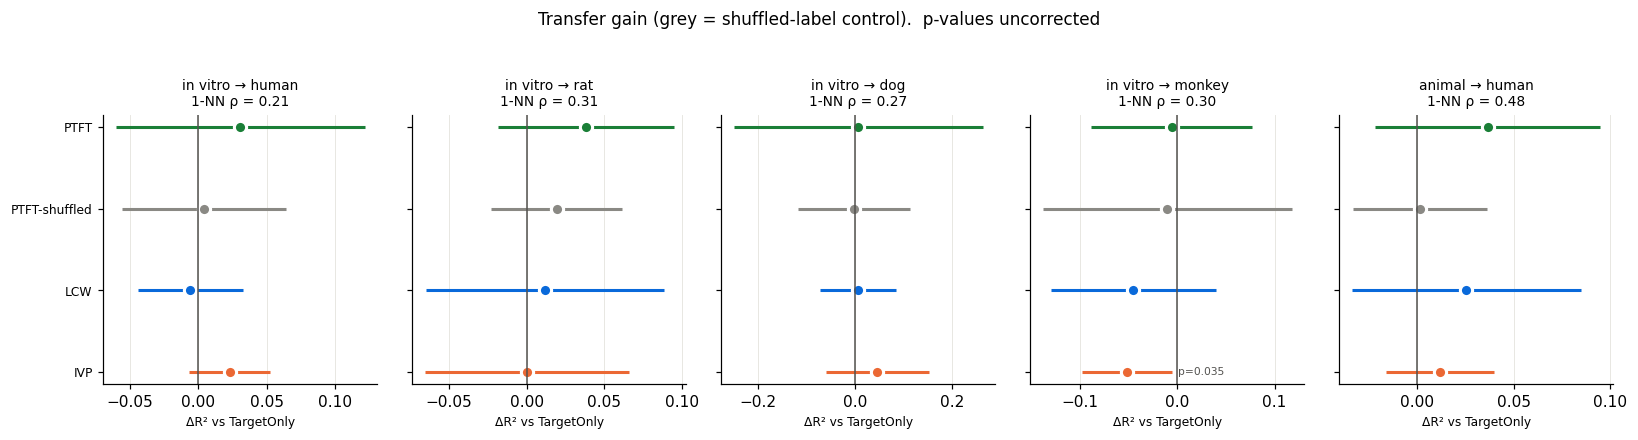

In [5]:
fig, axes = plt.subplots(1, len([p for p in ORDER if p in runs.pair.values]),
                         figsize=(15, 3.8), sharey=True)
for ax, p in zip(np.atleast_1d(axes), [p for p in ORDER if p in runs.pair.values]):
    ms = [m for m in METHODS if (p, m) in fold_mean.index]
    for i, m in enumerate(ms):
        d, half, pv = delta(p, m)
        y = len(ms) - 1 - i
        ax.hlines(y, d - half, d + half, color=COLOR[m], lw=2)
        ax.plot(d, y, 'o', ms=8, color=COLOR[m], mec='white', mew=2)
        if pv < 0.05:
            ax.annotate(f'p={pv:.3f}', (d + half, y), xytext=(4, 0), textcoords='offset points',
                        va='center', fontsize=7, color='#52514e')
    ax.axvline(0, color='#52514e', lw=1)
    ax.set_yticks(range(len(ms)))
    ax.set_yticklabels(ms[::-1], fontsize=8)
    rho = corr.set_index('pair').loc[p, 'nn_rho']
    ax.set_title(f'{p}\n1-NN ρ = {rho:.2f}', fontsize=9)
    ax.set_xlabel('ΔR² vs TargetOnly', fontsize=8)
    ax.grid(axis='y', visible=False)
fig.suptitle('Transfer gain (grey = shuffled-label control).  p-values uncorrected', fontsize=11, y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'cross_domain_forest.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Key figure — label correspondence vs transfer gain

If the hypothesis holds, points further right (higher correspondence) should sit higher (larger gain).
The three endpoints of the main experiment are placed on the same axes as well.

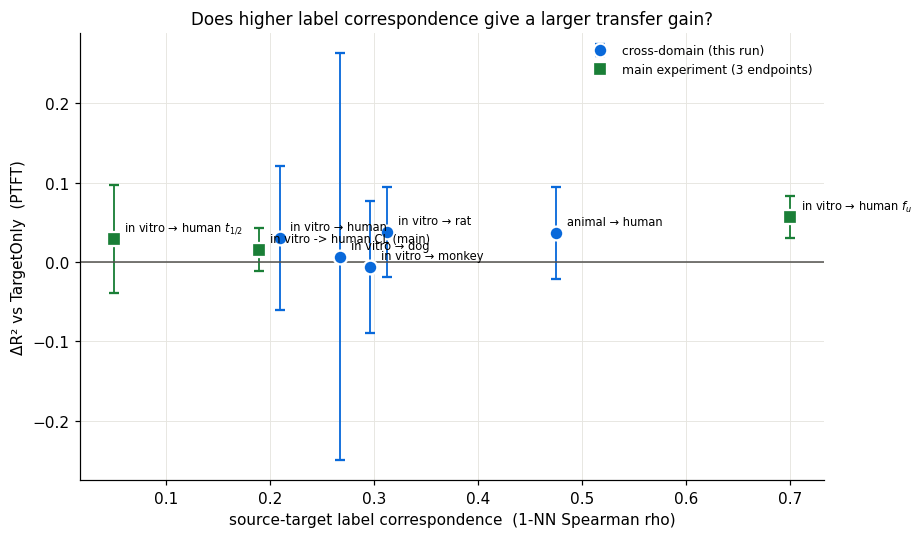

over 8 points: Spearman ρ(correspondence, gain) = +0.571
※ With so few points the correlation is for reference only. The confound of differing target sizes per point also remains.
                      label   rho      d  n_tgt
           in vitro → human 0.209  0.031    657
             in vitro → rat 0.313  0.038    203
             in vitro → dog 0.268  0.007    162
          in vitro → monkey 0.296 -0.006     78
             animal → human 0.475  0.036    657
     in vitro → human $f_u$ 0.700  0.057      5
in vitro -> human CL (main) 0.190  0.015      5
 in vitro → human $t_{1/2}$ 0.050  0.028      5


In [6]:
pts = []
for p in ORDER:
    if p in runs.pair.values and (p, 'PTFT') in fold_mean.index:
        d, half, _ = delta(p, 'PTFT')
        pts.append({'label': p, 'rho': corr.set_index('pair').loc[p, 'nn_rho'],
                    'd': d, 'half': half, 'group': 'cross-domain (this run)',
                    'n_tgt': int(corr.set_index('pair').loc[p, 'n_target_fit'])})

prop_path = os.path.join(ROOT, 'results', 'proposed', 'runs_rdkit.csv')
if os.path.exists(prop_path):
    pf = pd.read_csv(prop_path)
    NN = {'fu': 0.70, 'clearance': 0.19, 'half_life': 0.05}
    LAB = {'fu': 'in vitro → human $f_u$', 'clearance': 'in vitro -> human CL (main)',
           'half_life': 'in vitro → human $t_{1/2}$'}
    for prop, rho in NN.items():
        base = pf[(pf.method == 'TargetOnly') & (pf.property == prop)].groupby('fold').r2.mean()
        cur = pf[(pf.method == 'PTFT') & (pf.property == prop)].groupby('fold').r2.mean()
        dd = cur - base
        pts.append({'label': LAB[prop], 'rho': rho, 'd': dd.mean(),
                    'half': 2.776 * dd.std(ddof=1) / np.sqrt(len(dd)),
                    'group': 'main experiment (3 endpoints)', 'n_tgt': len(base)})

P_ = pd.DataFrame(pts)
fig, ax = plt.subplots(figsize=(8.5, 5))
for g, mk, c in [('cross-domain (this run)', 'o', '#0969da'), ('main experiment (3 endpoints)', 's', '#1a7f37')]:
    q = P_[P_.group == g]
    ax.errorbar(q.rho, q.d, yerr=q.half, fmt=mk, ms=9, mec='white', mew=1.5,
                color=c, capsize=3, lw=1.2, ls='none', label=g)
for r in P_.itertuples():
    ax.annotate(r.label, (r.rho, r.d), xytext=(7, 5), textcoords='offset points', fontsize=7.5)
ax.axhline(0, color='#52514e', lw=1)
ax.set_xlabel('source-target label correspondence  (1-NN Spearman rho)')
ax.set_ylabel('ΔR² vs TargetOnly  (PTFT)')
ax.legend(fontsize=8, frameon=False)
ax.set_title('Does higher label correspondence give a larger transfer gain?', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'correspondence_vs_gain.png'), dpi=150, bbox_inches='tight')
plt.show()

if len(P_) >= 4:
    print(f'Spearman ρ(correspondence, gain) over {len(P_)} points = {spearmanr(P_.rho, P_.d)[0]:+.3f}')
    print('※ With so few points the correlation is for reference only. The confound of differing target sizes per point also remains.')
    print(P_[['label', 'rho', 'd', 'n_tgt']].round(3).to_string(index=False))

## 5. Caveats for interpretation

1. **Do not mix the 1-NN approximation with direct measurement** — correspondence in sections 1 and 4 is the 1-NN approximation,
   section 2 is the direct correlation on the same molecules. Do not compare them on the same axis.
2. **The target-size confound remains** — target size differs per pair
   (human 657 / rat 203 / dog 162 / monkey 78). As the size ablation showed, smaller targets
   give larger transfer gains, so differences in gain cannot be attributed to correspondence alone.
3. **animal → human has a small source** — only 328 rows (2% of in vitro), so the pretraining effect is structurally limited.
   The gain may be small even with high correspondence, which does not refute the correspondence hypothesis.
4. **Power** — n for the paired test is 5 folds. The same limitation as the main experiment applies.
5. **t½ is not in the animal data** — comparisons are limited to clearance and f_u.